In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# ----------------------------------------------------------
# 1. Load X_train and dataset to align 24h targets
# ----------------------------------------------------------
X_train = np.load("X_train.npy")   # shape = (n_samples, 24, 35)
df = pd.read_csv("dataset_mansion_features_FINAL.csv", parse_dates=["MTime"])

WINDOW = 24
TARGET_STEPS = 24

# ----------------------------------------------------------
# 2. Build true next-24 target array
# ----------------------------------------------------------
true_24 = []

cons = df["Consumption"].values

for i in range(len(cons) - WINDOW - TARGET_STEPS):
    next24 = cons[i+WINDOW : i+WINDOW+TARGET_STEPS]
    true_24.append(next24)

true_24 = np.array(true_24, dtype=np.float32)

# Align lengths
X_24 = X_train[:len(true_24)]

print("X_24 shape:", X_24.shape)
print("true_24 shape:", true_24.shape)

# ----------------------------------------------------------
# 3. Build GRU 24-output Model (Stable Architecture)
# ----------------------------------------------------------
model = models.Sequential([
    layers.GRU(128, return_sequences=True, input_shape=(24, X_train.shape[-1])),
    layers.GRU(64, return_sequences=False),
    layers.Dense(64, activation="relu"),
    layers.Dense(24)   # <-- 24-hour output
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

# ----------------------------------------------------------
# 4. Train Model
# ----------------------------------------------------------
history = model.fit(
    X_24, true_24,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ----------------------------------------------------------
# 5. Save Model
# ----------------------------------------------------------
model.save("gru_24hour.keras")

print("GRU 24-hour model training complete!")


X_24 shape: (41427, 24, 35)
true_24 shape: (56014, 24)


/usr/local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 24, 128)        │        63,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,328 (415.34 KB)

 Trainable params: 106,328 (415.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6558 - mae: 0.4561 - val_loss: 0.0955 - val_mae: 0.1482
Epoch 2/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1198 - mae: 0.1632 - val_loss: 0.0775 - val_mae: 0.1165
Epoch 3/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1171 - mae: 0.1615 - val_loss: 0.0853 - val_mae: 0.1498
Epoch 4/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1100 - mae: 0.1625 - val_loss: 0.0809 - val_mae: 0.1333
Epoch 5/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0928 - mae: 0.1473 - val_loss: 0.0916 - val_mae: 0.1491
Epoch 6/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0800 - mae: 0.1408 - val_loss: 0.0925 - val_mae: 0.1458
Epoch 7/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0708 - mae: 0.1320 - val_loss: 0.0958 - val_mae: 0.1528
Epoch 8/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0653 - mae: 0.1295 - val_loss: 0.0982 - val_mae: 0.1926
Epoch 9/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

In [12]:
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model("gru_24hour.keras")
X_eval = np.load("X_eval.npy")

y_pred_24 = model.predict(X_eval)
np.save("y_pred_24.npy", y_pred_24)

print("Saved y_pred_24.npy with shape:", y_pred_24.shape)


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Saved y_pred_24.npy with shape: (5785, 24)


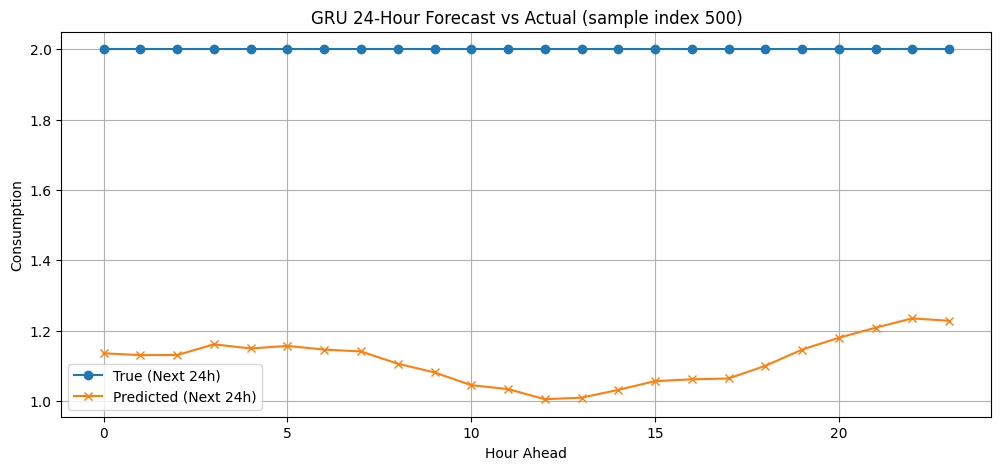

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 500

plt.figure(figsize=(12,5))
plt.plot(true_24[sample_idx], label="True (Next 24h)", marker="o")
plt.plot(y_pred_24[sample_idx], label="Predicted (Next 24h)", marker="x")
plt.title(f"GRU 24-Hour Forecast vs Actual (sample index {sample_idx})")
plt.xlabel("Hour Ahead")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.show()


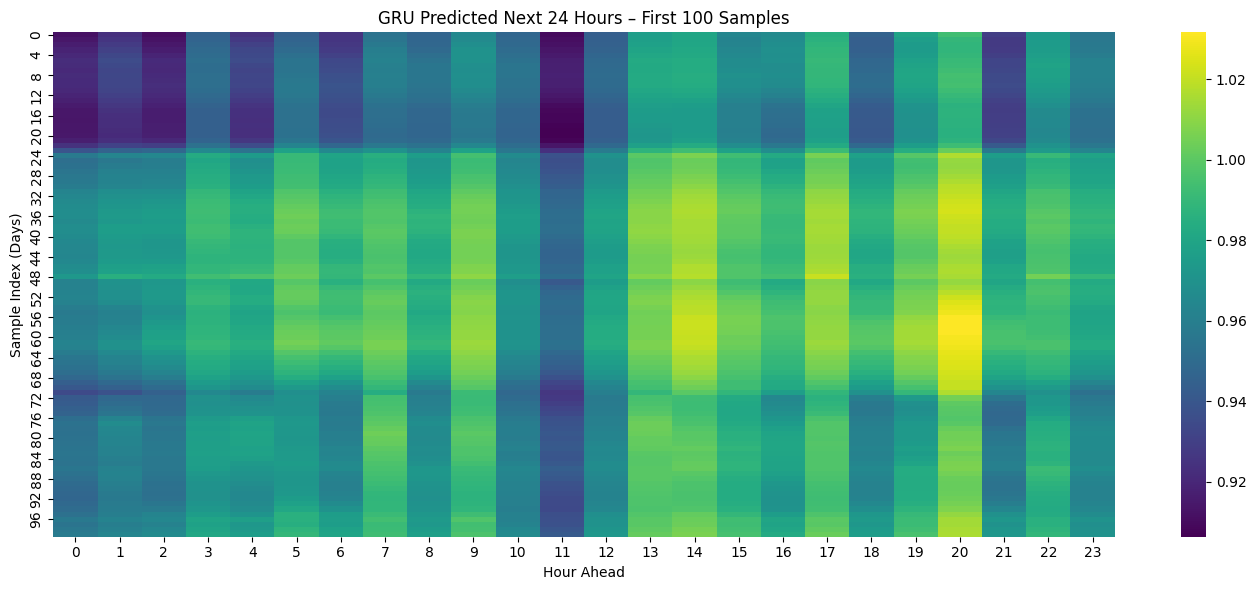

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.heatmap(y_pred_24[:100], cmap="viridis")
plt.title("GRU Predicted Next 24 Hours – First 100 Samples")
plt.xlabel("Hour Ahead")
plt.ylabel("Sample Index (Days)")
plt.tight_layout()
plt.show()


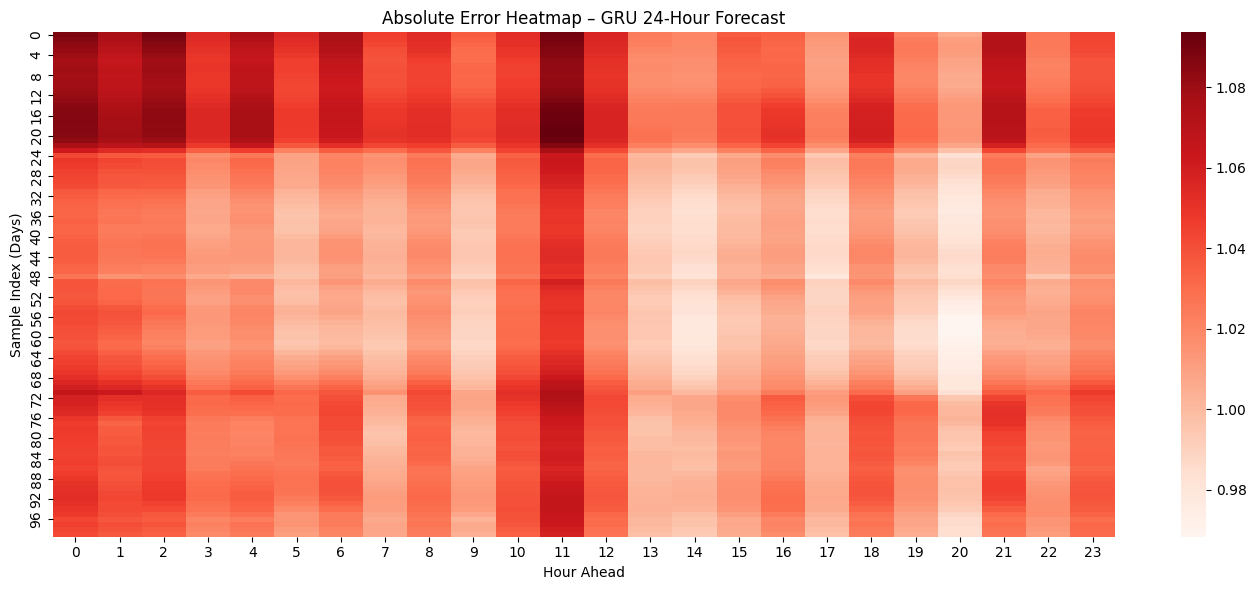

In [15]:
errors = np.abs(true_24[:len(y_pred_24)] - y_pred_24)

plt.figure(figsize=(14,6))
sns.heatmap(errors[:100], cmap="Reds")
plt.title("Absolute Error Heatmap – GRU 24-Hour Forecast")
plt.xlabel("Hour Ahead")
plt.ylabel("Sample Index (Days)")
plt.tight_layout()
plt.show()
